In [38]:
import numpy as np
import marimo as mo
import casadi as ca
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Projet optimisation

# Partie 1 :

1. * $P_i \Delta t$ correspond à l'énergie utilisée entre $t_i$ et $t_{i+1}$.
   * $c_i$ correspond au prix d'une unité d'énergie à l'instant $t_i$.  
    Donc le prix total est bien : $$\Delta t \sum_{i=0}^{N} P_i c_i$$

2. $$T_{i+1} = e^{-(k+h)\Delta t}T_i + \frac{1-e^{-(k+h)\Delta t}}{k+h}(bP_i + hT_e^i)$$

Cette équation vient du premier principe de la thermodynamique appliqué à la pièce de capacité calorifique 1/b entre $t_i$ et $t_{i+1}$. On obtient en fait une équation différentielle du premier ordre car $P_i$ et $T_e^i$ sont constant entre $t_i$ et $t_{i+1}$, qu'on peut facilement résoudre. Les termes suivants sont les puissances apportées entre $t_i$ et $t_{i+1}$:
* $Resistance$ $thermique*(T_e^i - T)$ : puissance reçue par l'extérieur (on a $h = \frac{1}{c*Resistance thermique}$)
* $P_i$ : puissance reçue par le chauffage
* $-kT$ : d'autres fuites thermiques pas liées à l'extérieur.

$\frac{1}{h}$ est le temps caractéristique lié spécifiquement aux échanges avec l'extérieur. $\frac{1}{k}$ est le temps caractéristique lié aux pertes intrinsèques du bâtiment
$\frac{1}{k+h}$ correspond au temps caractéristique de la perte globale de chaleur.


3. __Variables de décision__ : Les puissances $(P_i)_{i \in [0,N]}$ et les températures $(T_i)_{i \in [0,N]}$. Il y en a donc $2(N+1)$ variables. On regroupe toutes ces variables dans un vecteur $$x = \begin{bmatrix} P_0 \\ P_1 \\ \vdots \\ P_N \\ T_0 \\ T_1 \\ \vdots \\ T_N \end{bmatrix}\in \mathbb{R}^{2N+2}$$
__Contraintes d'égalité__ : il y'en a $N+2$ (Les N équations du premier principe et les 2 conditions initiales/terminales).
$$
\begin{array}{rcl}
c_{eq}:\mathbb{R}^{2N+2}&\to& \mathbb{R}^{N+2}\\
x &\mapsto &\begin{bmatrix} 
T_0 - T_{in} \\ 
P_N \\ 
T_1 - \Phi T_0 - \Psi (bP_0 + hT_e^0) \\ 
T_2 - \Phi T_1 - \Psi (bP_1 + hT_e^1) \\ 
\vdots \\ 
T_N - \Phi T_{N-1} - \Psi (bP_{N-1} + hT_e^{N-1}) 
\end{bmatrix}
\end{array}
$$
__Contraintes d'inégalité__: il y'en a $N+2$
$$
\begin{array}{rcl}
c_{eq}:\mathbb{R}^{2N+2}&\to& \mathbb{R}^{2(N+1+|I_{occ}|)}\\
x &\mapsto &\begin{bmatrix} 
P_0 - P_M \\ 
\vdots \\ 
P_N - P_M \\ 
-P_0 \\ 
\vdots \\ 
-P_N \\ 
T_m - T_{i_1} \\ 
\vdots \\ 
T_m - T_{i_{|I_{occ}|}} \\ 
T_{i_1} - T_M \\ 
\vdots \\ 
T_{i_{|I_{occ}|}} - T_M
\end{bmatrix}
\end{array}
$$

__Fonction objectif à minimiser__ : $f(x) = \Delta t \sum_{i=0}^{N} c_i P_i$.

Ainsi, le problème d'optimisation à résoudre est
$$
\begin{aligned}
\min_{x} \quad & f(x) \\
\text{tel que} \quad & c_{eq}(x) = 0, \\
& c_{in}(x) \leq 0
\end{aligned}
$$

4. * La fonction objectif $f$ est linéaire, donc convexe.
   * Les contraintes d'égalité $c_{eq}$ et d'inégalités $c_{in}$ sont aussi linéaires, donc convexes.
Le problème est donc convexe. Encore mieux, comme tout est linéaire, on a un problème linéaire. 

# Partie 2 :

5. Le problème étant linéaire, on pourrait utiliser l'algorithme du simplexe pour le résoudre. On peut aussi utiliser la méthode des points intérieurs, ce qu'on va faire avec une résolution numérique avec Casadis.

6. Résolution:

In [39]:
#définition des constantes:
delta_t = 0.3
t_0 = 23
c_cr = 1
c_pl = 3/2
T_m = 18
T_M = 30
T_in = T_m
h = 0.05
k = 0.01
b = 1/500
P_M = 5000
N = int(24/delta_t)
I_occ = []
cost = []
h_creuse = []
h_pleine = []

for i in range(N+1):
    hour = (t_0 + delta_t*i)%24
    if (hour >= 7 and hour <= 9) or (hour >= 18 and hour <= 23):
        I_occ.append(i)
    if (hour >= 0 and hour <= 6) or (hour >= 12 and hour <= 14):
        h_creuse.append(i)
        cost.append(c_cr)
    else:
        h_pleine.append(i)
        cost.append(c_pl)





#Fonction température extérieure:

def temp_ext(t):
    return 4 + 8*np.exp(-(t%24-12)**2/40)


In [40]:
P = ca.SX.sym('P', N+1)
T = ca.SX.sym('T', N+1)
x = ca.vertcat(P, T)

obj = delta_t*ca.dot(P, cost)

lbx = []
ubx = []

#bornes sur les Pi
for i in range(N):
    lbx.append(0)
    ubx.append(P_M)

#contraintes PN=0 et T0=Tin
lbx.append(0)
ubx.append(0)
lbx.append(T_in)
ubx.append(T_in)

#contraintes de confort sur les Ti pour i dans Iocc
for i in range(1, N+1):
    if i in I_occ:
        lbx.append(T_m)
        ubx.append(T_M)
    else:
        lbx.append(-ca.inf)
        ubx.append(ca.inf)

In [41]:
g = [T[i+1] - np.exp(-(k+h)*delta_t)*T[i] - (1-np.exp(-(k+h)*delta_t))/(k+h)*(b*P[i]+h*temp_ext((t_0 + delta_t*i)%24)) for i in range(N)]
lbg = [0 for i in range(N)]
ubg = [0 for i in range(N)]

g = ca.vertcat(*g)


In [42]:
lp = {
    'x': x,
    'f': obj,
    'g': g,
}

solver = ca.qpsol(
    'solver',
    'highs',
    lp
)

sol = solver(
    lbx=lbx,
    ubx=ubx,
    lbg=lbg,
    ubg=ubg
)

Puissance_sol = sol['x'][:N+1]
Temperature_sol = sol['x'][N+1:]

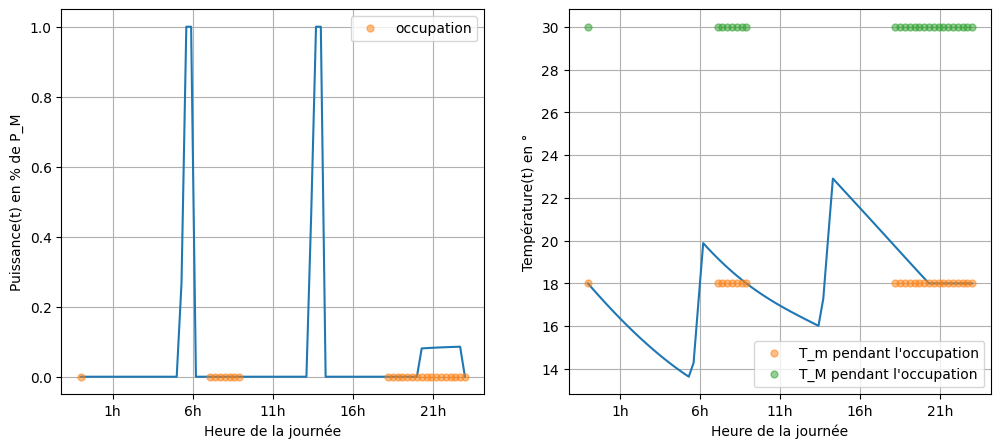

In [43]:
time_axis = [t_0 + delta_t * i for i in range(N+1)]
time_occ = [t_0 + delta_t * i for i in I_occ]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol/P_M)
axs[0].set_ylabel("Puissance(t) en % de P_M")
axs[0].plot(time_occ, [0 for i in range(len(time_occ))], marker='o', markersize=5, linewidth=0, alpha = 0.5, label = "occupation")
axs[1].plot(time_axis, Temperature_sol)
axs[1].plot(time_occ, [T_m for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_m pendant l'occupation")
axs[1].plot(time_occ, [T_M for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_M pendant l'occupation")
axs[1].set_ylabel("Température(t) en °")

def format_func(value, tick_number):
    return f"{int(value % 24)}h"

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

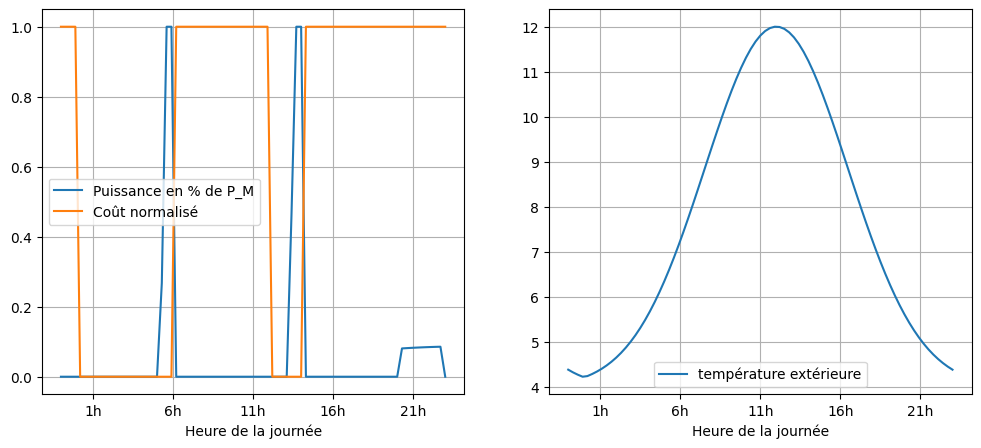

In [44]:
cost_normalized = [(cost[i]-c_cr)/(c_pl-c_cr) for i in range(len(cost))]
tempext = [temp_ext(t) for t in time_axis]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol/P_M, label="Puissance en % de P_M")
axs[0].plot(time_axis, cost_normalized, label = "Coût normalisé")
axs[1].plot(time_axis, tempext, label = "température extérieure")


for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

__Commentaires__: Le chauffage s'allume le plus tard possible dans la période creuse, pour payer moins cher tout en assurant les bornes des températures pendant les périodes d'occupation. On remarque cependant que à partir de 20h, la température allait passer en dessous de la borne inférieure, le chauffage se rallume donc, mais seulement assez pour assurer une température égale à la borne inférieure pendant la période pleine.

7. En augmentant le tarif heure pleine, on observe que le petit maintien de puissance en heure pleine (qu'ob observait à 20h dans la question précédente) disparaît complètement. Pour compenser ce manque à gagner thermique pendant la période d'occupation, le solveur allonge la durée de chauffe à pleine puissance ($P_M$) pendant les heures creuses. Le tarif a donc vraiment un effet incitatif sur le client, qui adapte sa stratégie de consommation pour payer le moins cher possible.

Partie 3

8. On considère maintenant la présence des logements autour, ce qui donne cette expression pour $T_{i+1}$ :

$$T_{i+1}^j = e^{-(k+h+ \sum_{k \neq j} h_{jk})\Delta t}T_i + \frac{1-e^{-(k+h+ \sum_{ k \neq j} h_{jk})\Delta t}}{k+h+\sum_{ i \neq j} h_{jk}}(bP_i + hT_e^i + \sum_{k \neq j} h_{jk}T_i^k )$$

* On considère $n_l$ habitations
* $ h_{jk} = h_{kj} \geq 0 $




Les variables de décision sont donc les puissances $(P_i^j)_{i,j \in [0,N]*[1,n_l]}$ et les températures $(T_i^j)_{i,j \in [0,N]*[1,n_l]}$. Il y en a donc $2n_l(N+1)$ variables, le vecteur de décision devient :
$$x = \begin{bmatrix} 
P_0^1 & \dots & P_N^1 & \dots & P_0^{n_l} & \dots & P_N^{n_l} & T_0^1 & \dots & T_N^1 & \dots & T_0^{n_l} & \dots & T_N^{n_l} 
\end{bmatrix}^T \in \mathbb{R}^{2 n_l (N+1)}$$


Pour chaque logement $j \in \{1, \dots, n_l\}$, on note  $\Phi_j$ et  $\Psi_j$ :
$$ \quad \Phi_j = e^{e^{-(k+h+ \sum_{k \neq j} h_{jk})\Delta t} \Delta t}, \quad \Psi_j = \frac{1 - e^{-e^{-(k+h+ \sum_{k \neq j} h_{jk})\Delta t} \Delta t}}{e^{-(k+h+ \sum_{k \neq j} h_{jk})\Delta t}}$$

La fonction des contraintes d'égalité $c_{eq} : \mathbb{R}^{2n_l(N+1)} \to \mathbb{R}^{n_l(N+2)}$ devient donc :

$$
c_{eq}(x) = \begin{bmatrix} 
\text{Bloc}_1 \\ 
\vdots \\ 
\text{Bloc}_j \\ 
\vdots \\ 
\text{Bloc}_{n_l} 
\end{bmatrix} 
\quad \text{où chaque } \text{Bloc}_j = \begin{bmatrix} 
T_0^j - T_{in} \\ 
P_N^j \\ 
T_1^j - \Phi_j T_0^j - \Psi_j \left( b P_0^j + h T_e^0 + \sum_{k \neq j} h_{jk} T_0^k \right) \\ 
\vdots \\ 
T_i^j - \Phi_j T_{i-1}^j - \Psi_j \left( b P_{i-1}^j + h T_e^{i-1} + \sum_{k \neq j} h_{jk} T_{i-1}^k \right) \\ 
\vdots \\ 
T_N^j - \Phi_j T_{N-1}^j - \Psi_j \left( b P_{N-1}^j + h T_e^{N-1} + \sum_{k \neq j} h_{jk} T_{N-1}^k \right)
\end{bmatrix}
$$

La fonction des contraintes d'inégalité $c_{in} : \mathbb{R}^{2n_l(N+1)} \to \mathbb{R}^{n_l(2(N+1) + 2|I_{occ}|)}$ assure le respect des limites de puissance et des plages de confort pour chaque logement $j \in \{1, \dots, n_l\}$ :

$$
c_{in}(x) = \begin{bmatrix} 
\text{Inégalités}_1 \\ 
\vdots \\ 
\text{Inégalités}_j \\ 
\vdots \\ 
\text{Inégalités}_{n_l} 
\end{bmatrix} \leq 0
\quad \text{où chaque } \text{Inégalités}_j = \begin{bmatrix} 
P_0^j - P_M \\ 
\vdots \\ 
P_N^j - P_M \\ 
-P_0^j \\ 
\vdots \\ 
-P_N^j \\ 
T_m^j - T_{i_1}^j \\ 
\vdots \\ 
T_m^j - T_{i_{|I_{occ}|}}^j \\ 
T_{i_1}^j - T_M \\ 
\vdots \\ 
T_{i_{|I_{occ}|}}^j - T_M
\end{bmatrix}
$$


La fonction objectif à minimiser devient donc :
$$f(x) = \Delta t \sum_{j=1}^{n_l} \sum_{i=0}^{N} c_i P_i^j$$

Ainsi, le problème d'optimisation à résoudre reste
$$
\begin{aligned}
\min_{x} \quad & f(x) \\
\text{tel que} \quad & c_{eq}(x) = 0, \\
& c_{in}(x) \leq 0
\end{aligned}
$$


9. 
__Avantages__ : Cette solution prend en compte les flux de chaleur entre les appartements, elle est donc plus réaliste, et cela réduit la consommation totale du bâtiment par rapport à des thermostats isolés. Cela permet de trouver un bon compromis pour minimiser la facture global : certains logement peuvent se chauffer plus tard en profitant de l'inertie des autres.

__Inconvénients__ : Il faut pour cela, avoir accès à beaucoup plus de données que précédemments, que ce soit les paramètres thermiques de chaque logements (les h, k etc), la tempréature en temps réelles de chaque pièce, mais aussi des données "privées" telles que les heures d'occupation du logement. De plus, la taille du vecteur de décision est multiplié par le nombre de logement, donc pour les grands immeubles, le temps de calcul peut-être long.

10. 


In [45]:
#définition des constantes:
delta_t = 0.3
t_0 = 23
c_cr = 1
c_pl = 3/2
T_1m = 18
T_2m = 20
T_M = 30
T_in1 = T_1m
T_in2 = T_2m
h = 0.05
k = 0.01
b = 1/500
P_M = 5000
N = int(24/delta_t)
n_l = 2
I_occ = []
cost = []
h_creuse = []
h_pleine = []

for i in range(N+1):
    hour = (t_0 + delta_t*i)%24
    if (hour >= 7 and hour <= 9) or (hour >= 18 and hour <= 23):
        I_occ.append(i)
    if (hour >= 0 and hour <= 6) or (hour >= 12 and hour <= 14):
        h_creuse.append(i)
        cost.append(c_cr)
    else:
        h_pleine.append(i)
        cost.append(c_pl)





#Fonction température extérieure:

def temp_ext(t):
    return 4 + 8*np.exp(-(t%24-12)**2/40)


In [46]:
P = ca.SX.sym('P', 2*(N+1))
T = ca.SX.sym('T', 2*(N+1))
x = ca.vertcat(P, T)

cost_total = ca.vertcat(cost, cost) 
obj = delta_t * ca.dot(P, cost_total)


lbx = []
ubx = []

# Bornes pour Pi (Logement 1 puis Logement 2)
for j in range(2): # Pour chaque logement
    for i in range(N):
        lbx.append(0)
        ubx.append(P_M)
    lbx.append(0) #contrainte PN = 0 pour les 2
    ubx.append(0)

# Bornes pour T (Logement 1 puis Logement 2) 
#logement1
lbx.append(T_in1) #contrainte T0 = Tin
ubx.append(T_in1)
for i in range(1, N+1):
    if i in I_occ:
        lbx.append(T_1m) 
        ubx.append(T_M)
    else:
        lbx.append(-ca.inf)
        ubx.append(ca.inf)

#logement2
lbx.append(T_in2) #contrainte T0 = Tin
ubx.append(T_in2)
for i in range(1, N+1):
    if i in I_occ:
        lbx.append(T_2m) 
        ubx.append(T_M)
    else:
        lbx.append(-ca.inf)
        ubx.append(ca.inf)

In [47]:
# On sépare les deux logements
P1 = P[:N+1]
P2 = P[N+1:]
T1 = T[:N+1]
T2 = T[N+1:]


g1 = [T1[i+1] - np.exp(-(k+h+h)*delta_t)*T1[i] - (1-np.exp(-(k+h+h)*delta_t))/(k+h+h)*(b*P1[i] + h*temp_ext((t_0 + delta_t*i)%24) + h*T2[i]) for i in range(N)]
g2 = [T2[i+1] - np.exp(-(k+h+h)*delta_t)*T2[i] - (1-np.exp(-(k+h+h)*delta_t))/(k+h+h)*(b*P2[i] + h*temp_ext((t_0 + delta_t*i)%24) + h*T1[i]) for i in range(N)]


lbg = [0 for i in range(2*N)]
ubg = [0 for i in range(2*N)]


g = ca.vertcat(*g1, *g2)

In [48]:
lp = {
    'x': x,
    'f': obj,
    'g': g,
}

solver = ca.qpsol(
    'solver',
    'highs',
    lp
)

sol = solver(
    lbx=lbx,
    ubx=ubx,
    lbg=lbg,
    ubg=ubg
)

Puissance_sol1 = sol['x'][:N+1]
Temperature_sol1 = sol['x'][2*(N+1):3*(N+1)]
Puissance_sol2 = sol['x'][N+1:2*(N+1)]
Temperature_sol2 = sol['x'][3*(N+1):]

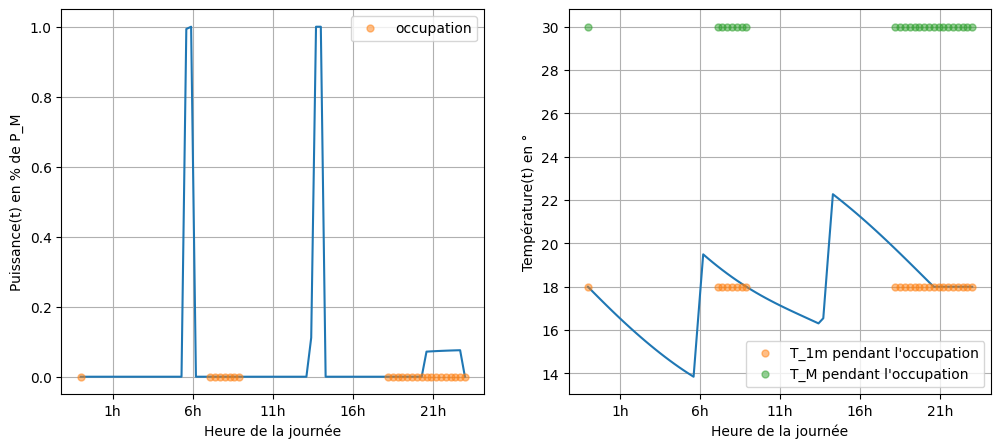

In [49]:
#logement 1

time_axis = [t_0 + delta_t * i for i in range(N+1)]
time_occ = [t_0 + delta_t * i for i in I_occ]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol1/P_M)
axs[0].set_ylabel("Puissance(t) en % de P_M")
axs[0].plot(time_occ, [0 for i in range(len(time_occ))], marker='o', markersize=5, linewidth=0, alpha = 0.5, label = "occupation")
axs[1].plot(time_axis, Temperature_sol1)
axs[1].plot(time_occ, [T_1m for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_1m pendant l'occupation")
axs[1].plot(time_occ, [T_M for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_M pendant l'occupation")
axs[1].set_ylabel("Température(t) en °")

def format_func(value, tick_number):
    return f"{int(value % 24)}h"

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

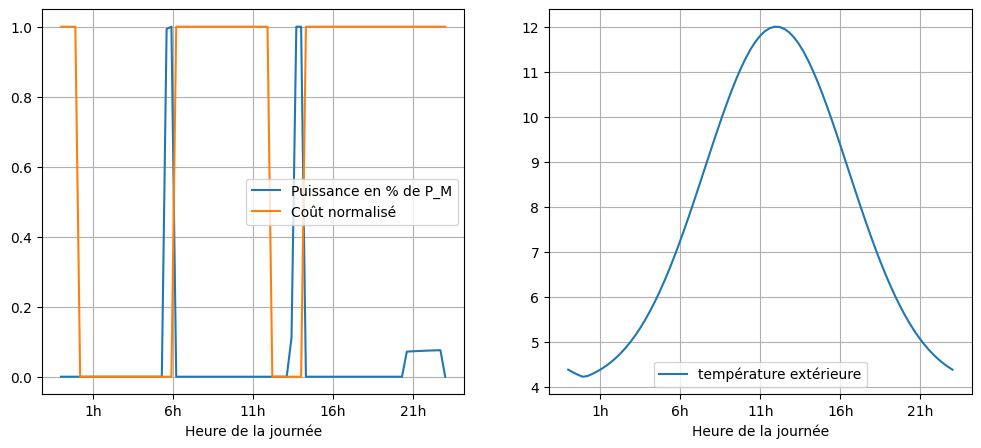

In [50]:
#logement 1

cost_normalized = [(cost[i]-c_cr)/(c_pl-c_cr) for i in range(len(cost))]
tempext = [temp_ext(t) for t in time_axis]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol1/P_M, label="Puissance en % de P_M")
axs[0].plot(time_axis, cost_normalized, label = "Coût normalisé")
axs[1].plot(time_axis, tempext, label = "température extérieure")


for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

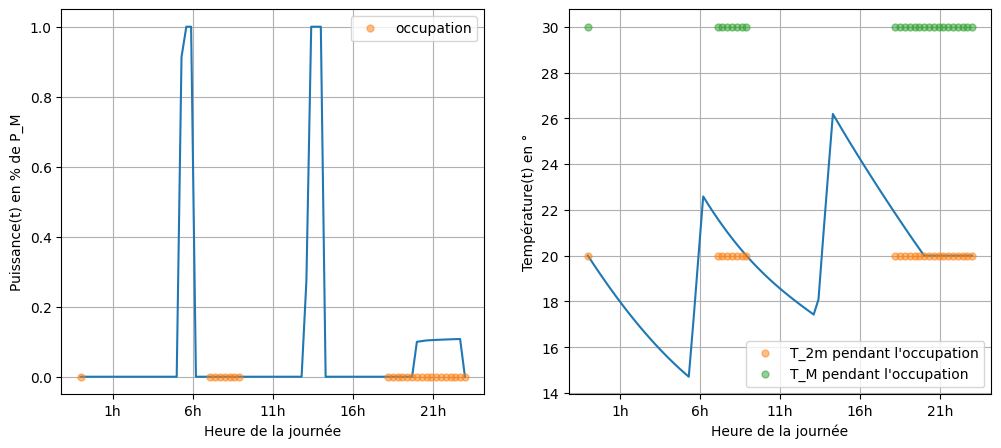

In [51]:
#logement 2

time_axis = [t_0 + delta_t * i for i in range(N+1)]
time_occ = [t_0 + delta_t * i for i in I_occ]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol2/P_M)
axs[0].set_ylabel("Puissance(t) en % de P_M")
axs[0].plot(time_occ, [0 for i in range(len(time_occ))], marker='o', markersize=5, linewidth=0, alpha = 0.5, label = "occupation")
axs[1].plot(time_axis, Temperature_sol2)
axs[1].plot(time_occ, [T_2m for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_2m pendant l'occupation")
axs[1].plot(time_occ, [T_M for i in range(len(time_occ))], marker='o', linewidth=0, markersize=5,alpha = 0.5, label = "T_M pendant l'occupation")
axs[1].set_ylabel("Température(t) en °")

def format_func(value, tick_number):
    return f"{int(value % 24)}h"

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

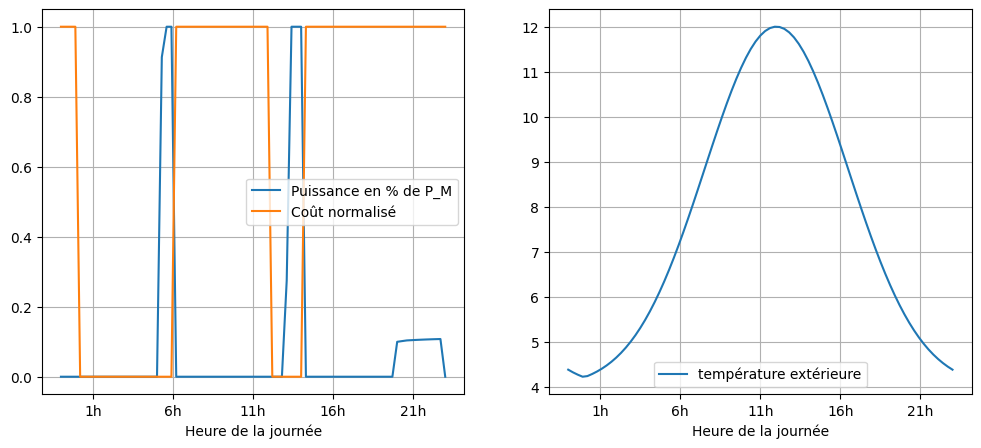

In [52]:
#logement 2

cost_normalized = [(cost[i]-c_cr)/(c_pl-c_cr) for i in range(len(cost))]
tempext = [temp_ext(t) for t in time_axis]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axs[0].plot(time_axis, Puissance_sol2/P_M, label="Puissance en % de P_M")
axs[0].plot(time_axis, cost_normalized, label = "Coût normalisé")
axs[1].plot(time_axis, tempext, label = "température extérieure")


for ax in axs:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    ax.set_xlabel("Heure de la journée")
    ax.grid()
    ax.legend()

plt.show()

__Commentaires__: On retrouve le même type de graphe que lorsqu'on ne prend pas en compte les autres logements (le chauffage s'allume le plus tard possible dans la période creuse, et se rallume pour maintenir la température à la temprérature inférieur). Cependant, on remqarque que le "pic" de puissance pour le logement 1 est moins large que celui du logement 2 (entre 5h et 6h puis entre 12h et 14h environ), cela peut signifier que le logement 1, qui a une température minimale plus petite "profite" du chauffage du logement 2, qui a une température minimale plus élevée.